In [90]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage
from langchain_groq import ChatGroq 
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langchain_core.messages import HumanMessage

In [91]:
load_dotenv()

True

In [92]:
# llm = ChatOpenAI(model="gpt-4.1-mini")?
llm=ChatGroq(model="Llama-3.3-70b-Versatile")

In [93]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [94]:
def chat_node(state: ChatState):

#this following code is for the human in the loop 
#firstly we have to create a interrupt which will pause the execution of workflow
#at a specific point
    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
    
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}



In [95]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

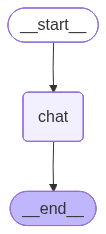

In [96]:
app

In [97]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages":[HumanMessage(content='what is 2 *8 please tell me answer in roman numbers')]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)

In [98]:
result

{'messages': [HumanMessage(content='what is 2 *8 please tell me answer in roman numbers', additional_kwargs={}, response_metadata={}, id='26642833-563c-455e-a40a-5cf1dd8cc0f8')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'what is 2 *8 please tell me answer in roman numbers', 'instruction': 'Approve this question? yes/no'}, id='06540076ea76ab73ac130bf243b43651')]}

In [99]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'what is 2 *8 please tell me answer in roman numbers',
 'instruction': 'Approve this question? yes/no'}

In [100]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")

In [101]:
# Resume the graph with the approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [102]:
print(final_result["messages"][-1].content)

Not approved.
